### University of Virginia
### DS 5110: Big Data Systems
### K-Means Cluster Analysis of Fidelity Fund Returns 
### Last updated: March 11, 2023

## Instructions

In this assignment, you will conduct a k-means cluster analysis on a set of Fidelity mutual funds.  
This helps to group similar funds based on their performance (as opposed to their description, which is typical).  
The outline below will walk you through the required steps.  

This assignment is worth a total of **10 POINTS.**

## Data Details 

The file *fido_returns_funds_on_rows.csv* is the processed data for k-means. Additional details about this file: 
- Each row represents a mutual fund  
- Each column represents a trading day (these are used as features)  
- Each value represents the daily percentage change in price between the current trading day and previous trading day

### Load Modules and Read Data into Spark DataFrame

In [28]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler

# Loads data
df = spark.read.csv("fido_returns_funds_on_rows.csv", header=True, inferSchema=True)

#Showing first 3 columns
df.select(df.columns[:5]).show(3)

+----------+----------+--------------------+--------------------+--------------------+
|2007-01-03|2007-01-04|          2007-01-05|          2007-01-08|          2007-01-09|
+----------+----------+--------------------+--------------------+--------------------+
|       0.0|       0.0|       -0.0104071952|0.003685507899999...|-0.00184105609999...|
|       0.0|       0.0|        -0.010516645|        0.0037243991|       -0.0012399258|
|       0.0|       0.0|-0.01076436659999...|        0.0037807228|-0.00161855980000...|
+----------+----------+--------------------+--------------------+--------------------+
only showing top 3 rows



**(VALUE: 2 POINTS) Assemble the Features into a column. 
Show the first five rows of data ONLY for the features column.
(this should make things easier to read)**

In [29]:
from pyspark.ml.feature import VectorAssembler

feature_cols = df.columns

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

dataset = assembler.transform(df)

#Show the first five rows ONLY for the features column
dataset.select("features").show(5, truncate=True)

+--------------------+
|            features|
+--------------------+
|[0.0,0.0,-0.01040...|
|[0.0,0.0,-0.01051...|
|[0.0,0.0,-0.01076...|
|[0.0,8.26105E-4,-...|
|[0.0,8.2815740000...|
+--------------------+
only showing top 5 rows



**(VALUE: 1 POINT) Set up the k-means model and train the model**  
Use parameters: 
- 3 clusters
- maximum of 10 iterations 
- seed=314

In [30]:
kmeans = KMeans().setK(3).setSeed(314).setMaxIter(10)
model = kmeans.fit(dataset)

predictions = model.transform(dataset)

[Stage 681:============================>                            (2 + 2) / 4]

26/07/11 03:06:12 WARN DAGScheduler: Broadcasting large task binary with size 1028.9 KiB


**(VALUE: 2 POINTS) Compute and Print the Silhouette Score**  

In [31]:
# Evaluate clustering by computing Silhouette Score
evaluator = ClusteringEvaluator()

silhouette = evaluator.evaluate(predictions)
print("Silhouette with squared euclidean distance = " + str(silhouette))

print("Cluster Centers: ")
centers = model.clusterCenters()
print(centers)

[Stage 686:==============>                                          (1 + 3) / 4]

Silhouette with squared euclidean distance = 0.4227167920104707
Cluster Centers: 
[array([ 0.        , -0.00163056, -0.00514306, ...,  0.00205666,
       -0.01069438,  0.00511193]), array([ 0.00000000e+00,  3.38239563e-04, -5.47052304e-04, ...,
        1.22111563e-03, -4.18808185e-03, -6.74598750e-06]), array([ 0.        ,  0.0004711 , -0.00681281, ...,  0.00156409,
       -0.015003  ,  0.01300299])]


**(VALUE: 2 POINTS) Define a function `kmeans_range()` that does the following:**
- takes an integer representing the lower bound for k
- takes an integer representing the upper bound for k
- take a Spark DataFrame containing training data
- fit K-means with k ranging from lower bound to upper bound, inclusive  
- the other parameters should be the same as earlier 
- for each k, compute the silhouette score
- return a pandas dataframe with columns containing k, silhouette score (each row holds the score for given k)

In [32]:
import pandas as pd

def kmeans_range(lower_bound, upper_bound, training_data):
    results = []
    
    for k in range(lower_bound, upper_bound + 1):
        # Configure model with assignment parameters
        kmeans = KMeans().setK(k).setSeed(314).setMaxIter(10)
        model = kmeans.fit(training_data)
        
        # Formulate predictions and evaluate
        predictions = model.transform(training_data)
        evaluator = ClusteringEvaluator()
        silhouette_score = evaluator.evaluate(predictions)
        
        # Track results
        results.append({"k": k, "silhouette_score": silhouette_score})
        
    #Return results
    return pd.DataFrame(results)

**(VALUE: 1 POINT) Call `kmeans_range` to compute K-means with clusters ranging from 2 to 10 inclusive, printing the resulting dataframe.**

In [33]:
# Run the range iteration ranging from 2 to 10 clusters inclusive
range_results = kmeans_range(2, 10, dataset)

# Print the resulting dataframe
print(range_results)

[Stage 707:==========================================>              (3 + 1) / 4]

26/07/11 03:06:18 WARN DAGScheduler: Broadcasting large task binary with size 1015.4 KiB


[Stage 737:==============>                                          (1 + 3) / 4]

26/07/11 03:06:24 WARN DAGScheduler: Broadcasting large task binary with size 1028.9 KiB


[Stage 773:==========================================>              (3 + 1) / 4]

...

[Stage 905:==============>                                          (1 + 3) / 4]

26/07/11 03:07:01 WARN DAGScheduler: Broadcasting large task binary with size 1110.2 KiB


[Stage 941:==========================================>              (3 + 1) / 4]

26/07/11 03:07:07 WARN DAGScheduler: Broadcasting large task binary with size 1123.7 KiB


    k  silhouette_score
0   2          0.602396
1   3          0.422717
2   4          0.500796
3   5          0.459791
4   6          0.445675
5   7          0.382670
6   8          0.410208
7   9          0.513384
8  10          0.455571


**(VALUE: 1 POINT) Produce a plot with cluster numbers k on the x-axis, sihouette scores on the y-axis**

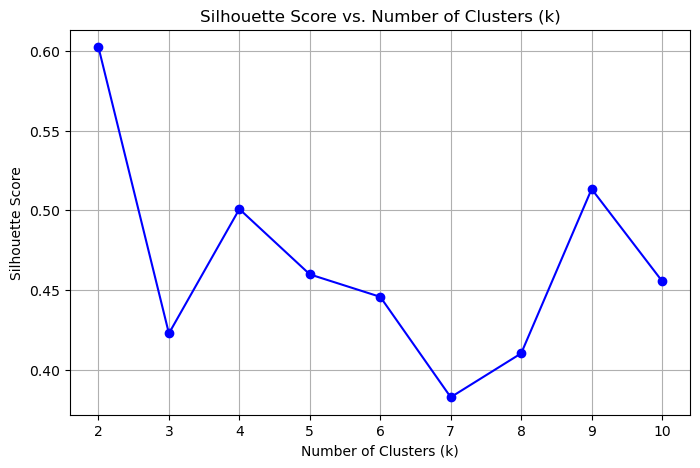

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range_results['k'], range_results['silhouette_score'], marker='o', color='b', linestyle='-')
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

**(VALUE: 1 POINT) Based on how the silhouette score is calculated, what is its time complexity? (e.g., O(log n))**  
You can find the definition of the silhouette score in the lecture notes, for example. 

O(n^2)